<center> <span style="color:indigo">Matemáticas Aplicadas a Ciencia de Datos</span> </center> 

<div style="text-align: center;">
<img src="https://upload.wikimedia.org/wikipedia/commons/2/2b/Centro_Universitario_del_Guadalajara_Logo.png" alt="Drawing" style="width: 800px;"/>
</div>

<center> <span style="color:DarkBlue">  Examen 2. Series de tiempo. ARIMA, SARIMA, SARIMAX  </span>  </center>
<center> <span style="color:Blue"> Profesor: M. en C. Iván A. Toledano Juárez </span>  </center>

Este examen se basa en análisis de series de tiempo mediante modelos ARIMA, SARIMA y SARIMAX.  
El objetivo es que apliques los conceptos vistos en clase: identificación del modelo, análisis gráfico, ajuste, diagnóstico y comparación de modelos.

---

## Un poco de contexto de los datos

Para este examen utilizaremos una serie de tiempo que simula el comportamiento mensual del número de pasajeros de una aerolínea comercial entre los años 1949 y 1960. La serie presenta tendencia y un patrón estacional claro, por lo que es ideal para discutir modelos SARIMA.

También se incluye una variable exógena opcional llamada `promotion`, que representa un índice mensual de gasto publicitario de la aerolínea. Aunque en este caso la influencia de la variable exógena no es muy fuerte, servirá para mostrar el procedimiento general del modelo SARIMAX.


In [135]:
# Importación de librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scipy
from scipy.stats import boxcox

# statsmodels
from statsmodels.graphics.tsaplots import month_plot, quarter_plot, plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

# scikit-learn
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import ParameterGrid, TimeSeriesSplit

In [136]:
## Funciones útiles

def model_plot(train, test, predictions, chart_title):
    
    plt.figure(figsize=(10,4))
    plt.plot(train, label='Train')
    plt.plot(test, label='Test')
    plt.plot(predictions, label='Forecast')
    plt.title(f'Entrenamiento, Validación, y Predicciones con {chart_title}')
    plt.legend()
    plt.show()

    mae = mean_absolute_error(test, predictions)
    rmse = root_mean_squared_error(test, predictions)
    mape = mean_absolute_percentage_error(test, predictions)

    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {100*mape:.2f} %")

In [137]:
# Importacion de datos
df = pd.read_csv("data/airline-passenger-traffic_revised.csv", index_col="Month", parse_dates=True)
df_exog = pd.read_csv("data/promotion.csv", index_col="Month", parse_dates=True)

# Ponemos la frecuencias como mensual (start)
df = df.dropna().asfreq("MS")
df_exog = df_exog.dropna().asfreq("MS")

# Cambiamos el nombre de la variable objetivo para mayor facilidad
df = df.rename(columns={'Passengers':'y'})
df_exog = df_exog.rename(columns={'Event':'y'})

display(df_exog.head())
display(df.head())

,y
Month,
1949-01-01,0
1949-02-01,0
1949-03-01,0
1949-04-01,0
1949-05-01,0


,y
Month,
1949-01-01,112.0
1949-02-01,118.0
1949-03-01,132.0
1949-04-01,129.0
1949-05-01,121.0


## Objetivo del examen

A partir de la serie temporal proporcionada, deberás:

1. **Explorar la serie** mediante gráficos, descomposición y estadísticos básicos.
2. **Analizar estacionariedad** con ADF y diferenciación.
3. **Dividir los datos en entrenamiento y validación**
4. **Proponer un modelo ARIMA** basado en ACF y PACF.
5. **Extender el análisis a SARIMA**, usando el componente estacional.
6. **Crear y ajustar un modelo SARIMAX**, usando la variable `promotion`.
7. **Aplicar validación cruzada para series de tiempo**
8. **Comparar resultados** en términos de métricas de error y el comportamiento del pronóstico.
9. **Responder preguntas teóricas** sobre las diferencias entre ARIMA, SARIMA y SARIMAX.

Por favor crea celdas que respondan a cada una de las siguientes preguntas. Cada sección vale 1 punto (sobre 10 puntos totales).


## 1. Exploración inicial de la serie

Realiza:
- Un gráfico de la serie original.
- Una descomposición aditiva o multiplicativa.
- Un análisis descriptivo (mínimo, máximo, tendencia aparente).


In [138]:
#Sacamos Informacion de los dataframes
print('Info del df pasajeros')
display(df.info())
print('\nInfo del df promociones')
display(df_exog.info())

Info del df pasajeros
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Freq: MS
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   y       144 non-null    float64
dtypes: float64(1)
memory usage: 2.2 KB


None


Info del df promociones
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Freq: MS
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   y       144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


None

In [139]:
#Medidas de tendecia central
display(df.describe())
display(df_exog.describe())

,y
count,144.000000
mean,280.333333
std,120.048359
min,104.000000
25%,180.750000
50%,267.500000
75%,360.500000
max,622.000000


,y
count,144.000000
mean,0.236111
std,0.426174
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [140]:
# Ponemos la frecuencias como Mensual
df = df.asfreq("MS")
df_exog = df_exog.asfreq("MS")

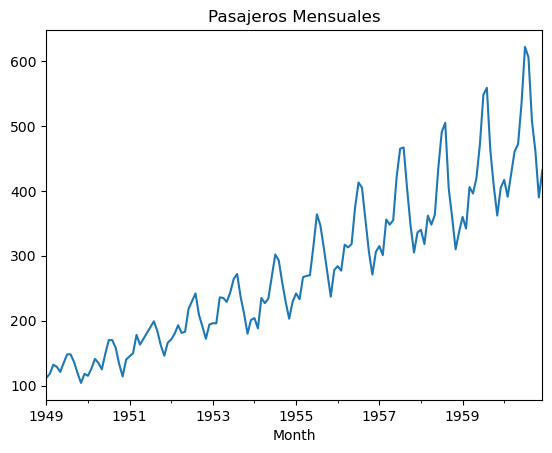

In [141]:
# Plots simples
df['y'].plot(title='Pasajeros Mensuales')
plt.show()

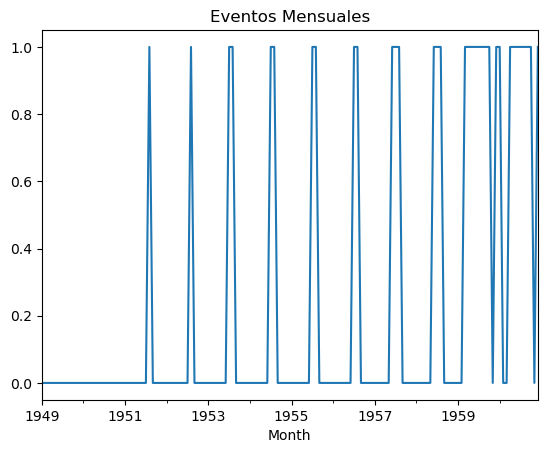

In [142]:
df_exog['y'].plot(title='Eventos Mensuales')
plt.show()

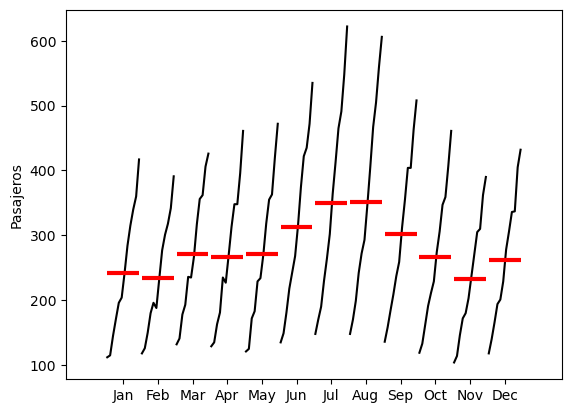

In [143]:
# Gráfico por mes
month_plot(df['y'].resample('MS').mean(),
           ylabel='Pasajeros')
plt.show()

Tenemos Un incremento en el Q2, Q3 y decremento en Q4

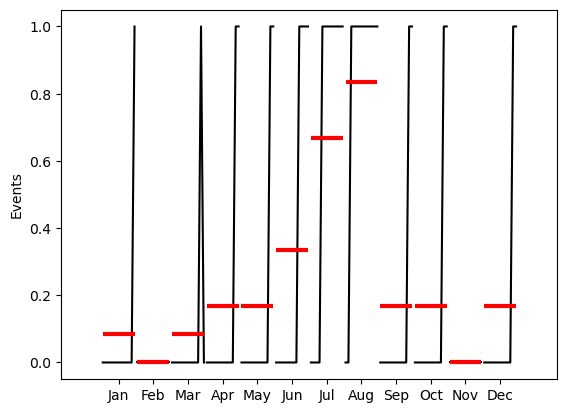

In [144]:
month_plot(df_exog['y'].resample('MS').mean(),
           ylabel='Events')
plt.show()

???

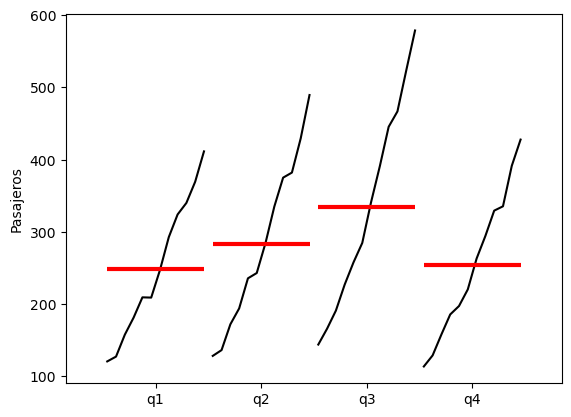

In [145]:
# Gráfico por quarter
quarter_plot(df['y'].resample('QE').mean(),
           ylabel='Pasajeros')
plt.show()

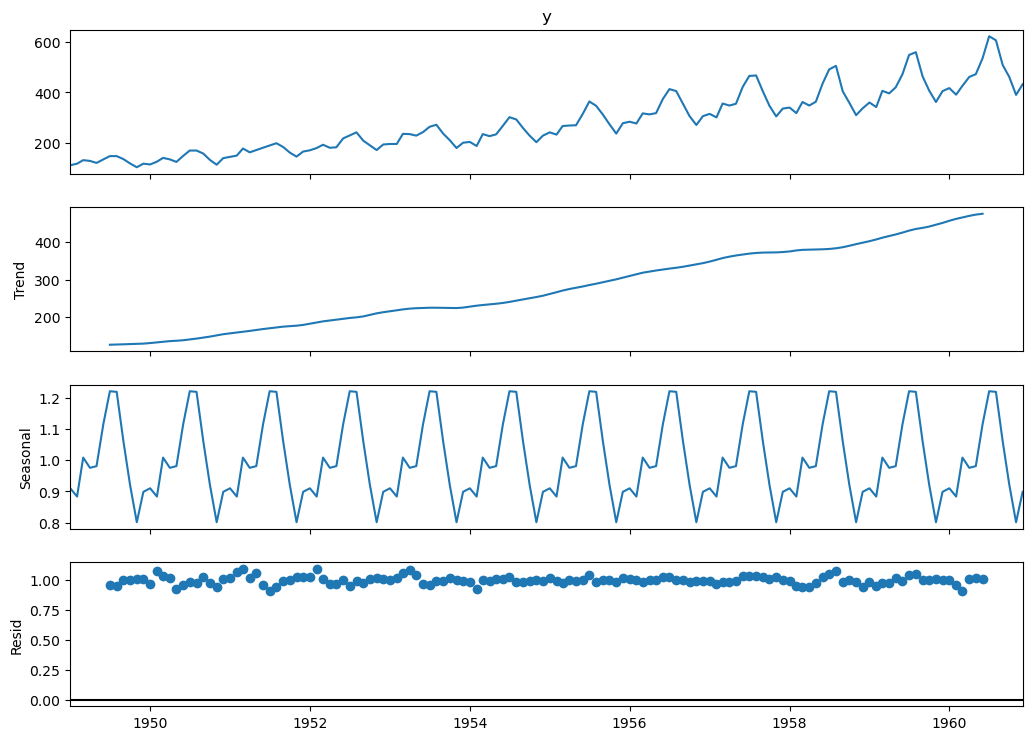

In [146]:
# Seasonal decomposition
decomposition = seasonal_decompose(df['y'],
                                   model='mul',
                                   period=12)
fig = decomposition.plot()
fig.set_size_inches(11,8)
plt.show()

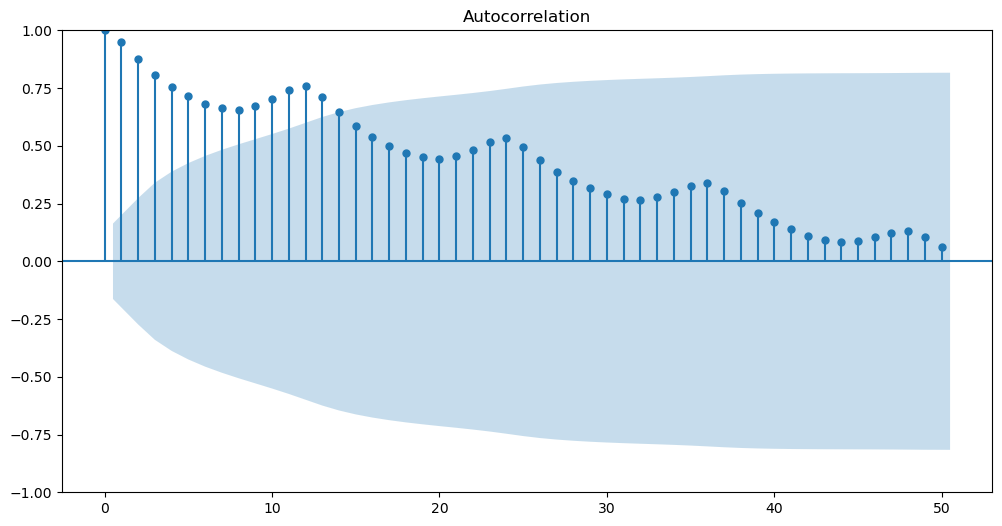

In [147]:
# Gráfico de autocorrelacion
fig, ax = plt.subplots(figsize=(12,6))
plot_acf(df['y'], lags=50, ax=ax)
plt.show()

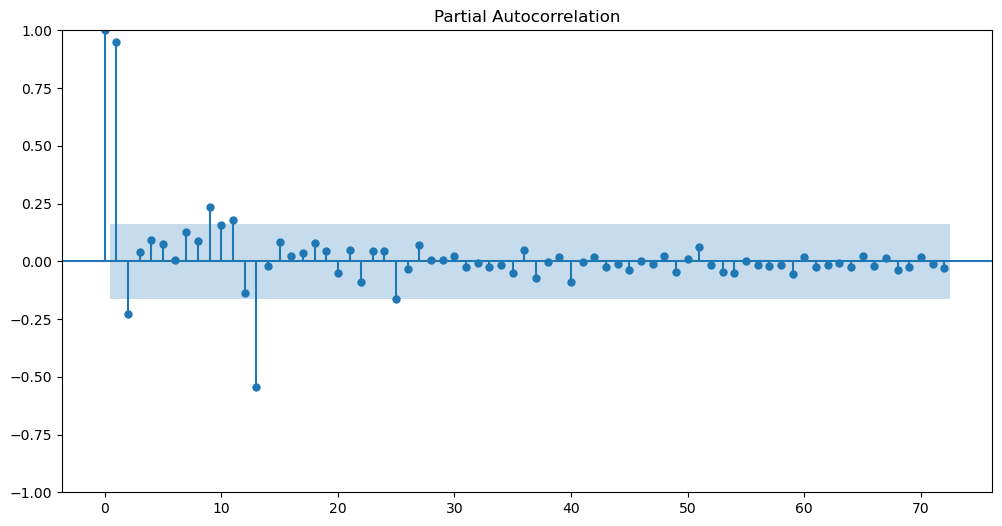

In [148]:
# Gráfico de autocorrelacion parcial
fig, ax = plt.  subplots(figsize=(12,6))
plot_pacf(df['y'], lags=72, ax=ax)
plt.show()

## 2. Prueba de estacionariedad (ADF Test)

Ejecuta la prueba ADF e interpreta:
- ¿La serie es estacionaria?
- ¿Qué orden de diferenciación parece apropiado?


In [149]:
# Prueba de adfuller
adfuller(df.y)

(np.float64(0.8946087940823834),
 np.float64(0.9930195647605924),
 13,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(993.7736365973918))

In [150]:
result = adfuller(df.y)
print(f"p-value: {result[1]}")

significance = 0.05
if result[1] > significance:
    print("La serie de tiempo no es estacionaria")
else:
    print("Es probable que la serie de tiempo sea estacionaria")

p-value: 0.9930195647605924
La serie de tiempo no es estacionaria


In [151]:
# Diferenciación para df.y
df['y_diff'] = df['y'].diff()
df.head()

,y,y_diff
Month,,
1949-01-01,112.0,NaN
1949-02-01,118.0,6.0
1949-03-01,132.0,14.0
1949-04-01,129.0,-3.0
1949-05-01,121.0,-8.0


In [152]:
# Prueba después de la diferenciación

result = adfuller(df.y_diff.dropna()) # le quitamos los primero valores nulos debido al método
print(f"p-value: {result[1]}")

significance = 0.05
if result[1] > significance:
    print("La serie de tiempo no es estacionaria")
else:
    print("Es probable que la serie de tiempo sea estacionaria")

p-value: 0.04492887012840053
Es probable que la serie de tiempo sea estacionaria


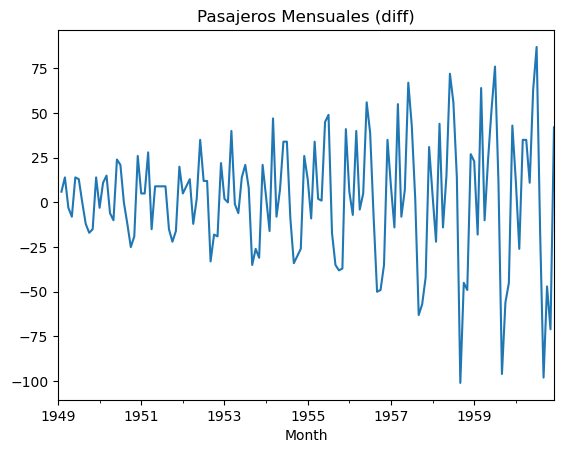

In [153]:
# Plot simple
df['y_diff'].plot(title='Pasajeros Mensuales (diff)')
plt.show()

## 3. División de datos de entrenamiento y validación
- Realiza la división tanto para la variable endog como la variable exog.
- Toma 12 periodos (12 meses) como el bloque de validación.

In [154]:
# Datos de entrenamiento y validación
test_months = 12
train_endog = df.iloc[:-test_months]
test_endog = df.iloc[-test_months:]
display(test_endog.head())

train_exog = df_exog.iloc[:-test_months]
test_exog = df_exog.iloc[-test_months:]
display(test_exog.head())


,y,y_diff
Month,,
1960-01-01,417.0,12.0
1960-02-01,391.0,-26.0
1960-03-01,426.0,35.0
1960-04-01,461.0,35.0
1960-05-01,472.0,11.0


,y
Month,
1960-01-01,1
1960-02-01,0
1960-03-01,0
1960-04-01,1
1960-05-01,1


## 4. Identificación e implementación del modelo ARIMA

Usa ACF/PACF para sugerir valores de:
- p (autoregresivo)
- d (diferenciación)
- q (media móvil)


In [155]:
# Crear el modelo ARIMA
arima_model = SARIMAX(train['y'],
                order=(3,1,1), ## p, d, q
                exog=None, ## variables externas
                seasonal_order=(0,0,0,0)).fit() # para ARIMA, (0,0,0,0)
print(arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  132
Model:               SARIMAX(3, 1, 1)   Log Likelihood                -618.584
Date:                Sat, 29 Nov 2025   AIC                           1247.168
Time:                        20:26:59   BIC                           1261.544
Sample:                    01-01-1949   HQIC                          1253.010
                         - 12-01-1959                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0204      0.115      8.898      0.000       0.796       1.245
ar.L2         -0.3885      0.137     -2.838      0.005      -0.657      -0.120
ar.L3         -0.0829      0.102     -0.812      0.4

In [156]:
# Predicciones con ARIMA
arima_pred = model.forecast(steps = test_months).to_frame()

arima_pred

,predicted_mean
1960-01-01,435.855990
1960-02-01,454.365865
1960-03-01,457.701432
1960-04-01,451.356559
1960-05-01,442.052403
1960-06-01,434.747158
1960-07-01,431.433560
1960-08-01,431.661651
1960-09-01,433.787183
1960-10-01,436.142052


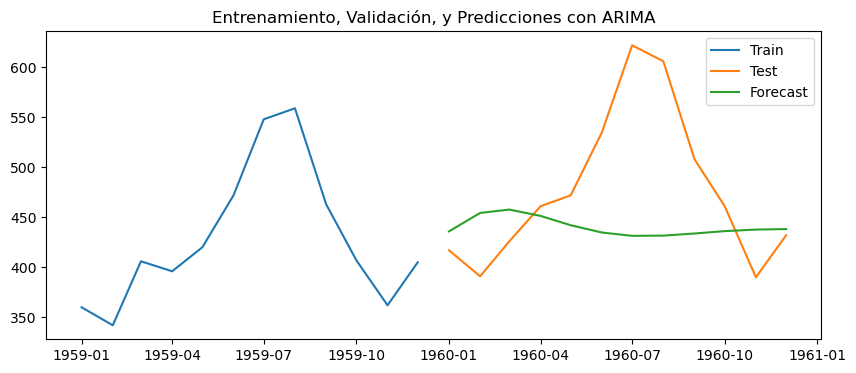

MAE: 64.30
RMSE: 87.35
MAPE: 12.37 %


In [157]:
# Visualización del pronóstico
model_plot(train['y']['1959':'1961'], test['y'], arima_pred, 'ARIMA')

## 5. Ajuste del modelo SARIMA

Incluye términos estacionales (P,D,Q,s).

Explica:
- Por qué es necesario incluir estacionalidad.

In [158]:
# Crear el modelo SARIMA
model_sarima = SARIMAX(train_endog['y'],
                       order=(3, 1, 1),
                       seasonal_order=(1, 1, 1, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

sarima_results = sarima_model.fit()
print(sarima_results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  132
Model:             SARIMAX(3, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -390.655
Date:                            Sat, 29 Nov 2025   AIC                            795.310
Time:                                    20:27:01   BIC                            813.821
Sample:                                01-01-1949   HQIC                           802.809
                                     - 12-01-1959                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7251      0.111      6.534      0.000       0.508       0.943
ar.L2          0.1851      0.149   

In [159]:
# Predicciones con SARIMA
sarima_pred = sarima_results.get_forecast(steps=len(test_endog))
sarima_pred_mean = sarima_pred.predicted_mean
sarima_pred_conf = sarima_pred.conf_int()


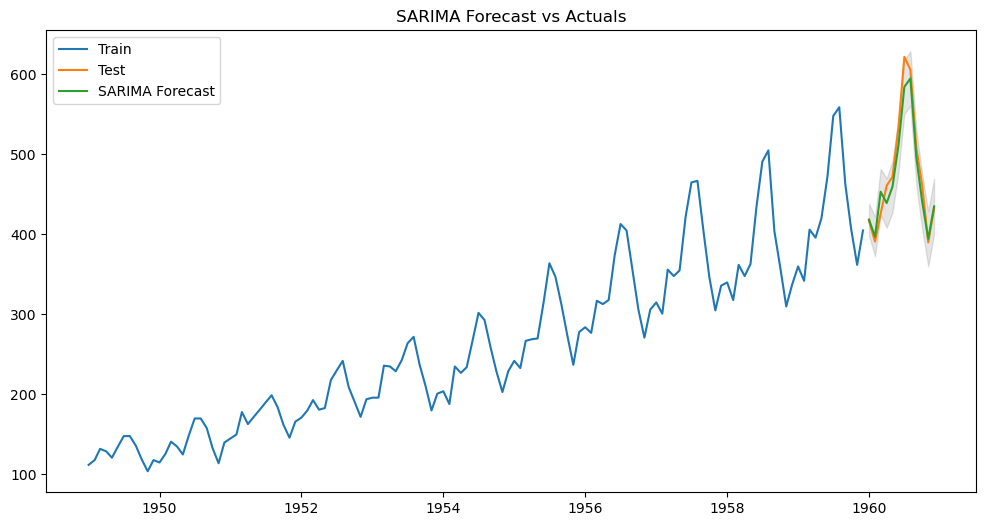

SARIMA MAE: 15.1281
SARIMA RMSE: 18.4472
SARIMA MAPE: 3.06 %


In [160]:
# Graficas
plt.figure(figsize=(12, 6))
plt.plot(train_endog['y'], label='Train')
plt.plot(test_endog['y'], label='Test')
plt.plot(sarima_pred_mean, label='SARIMA Forecast')
plt.fill_between(sarima_pred_conf.index,
                 sarima_pred_conf.iloc[:, 0],
                 sarima_pred_conf.iloc[:, 1], color='k', alpha=0.1)
plt.title('SARIMA Forecast vs Actuals')
plt.legend()
plt.show()

# Métricas
mae_sarima = mean_absolute_error(test_endog['y'], sarima_pred_mean)
rmse_sarima = root_mean_squared_error(test_endog['y'], sarima_pred_mean)
mape_sarima = mean_absolute_percentage_error(test_endog['y'], sarima_pred_mean)

print(f"SARIMA MAE: {mae_sarima:.4f}")
print(f"SARIMA RMSE: {rmse_sarima:.4f}")
print(f"SARIMA MAPE: {100*mape_sarima:.2f} %")

## 6. Comparación del pronóstico ARIMA vs SARIMA

Realiza:
- gráfico de los últimos 24 meses
- gráfico de 12 meses futuros
- tabla comparativa de métricas

Justifica cuál modelo representa mejor la estructura temporal.

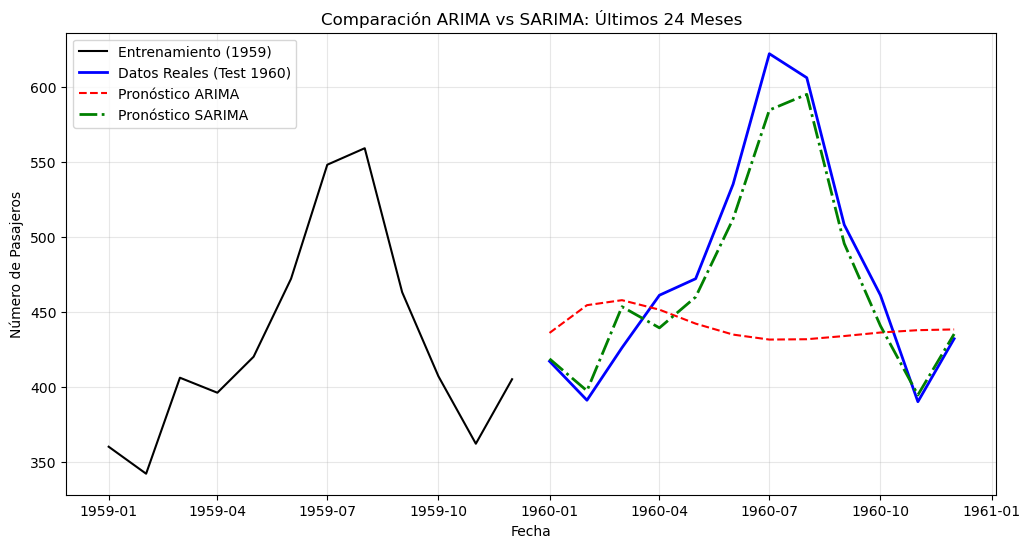


--- Tabla Comparativa de Errores ---


,Métrica,ARIMA,SARIMA,Mejora (SARIMA vs ARIMA)
0,MAE,64.30,15.128105,76.47%
1,RMSE,87.35,18.447230,78.88%
2,MAPE (%),12.37,3.056748,75.29%


In [161]:
# Gráfico comparativo (Últimos 24 meses: 12 de entrenamiento + 12 de prueba)
plt.figure(figsize=(12, 6))

# Datos reales: Último año de entrenamiento y año de prueba
plt.plot(train_endog['y']['1959':], label='Entrenamiento (1959)', color='black')
plt.plot(test_endog['y'], label='Datos Reales (Test 1960)', color='blue', linewidth=2)

# Pronósticos
plt.plot(test_endog.index, predictions, label='Pronóstico ARIMA', linestyle='--', color='red')
plt.plot(test_endog.index, sarima_pred_mean, label='Pronóstico SARIMA', linestyle='-.', color='green', linewidth=2)

plt.title('Comparación ARIMA vs SARIMA: Últimos 24 Meses')
plt.ylabel('Número de Pasajeros')
plt.xlabel('Fecha')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Tabla Comparativa de Métricas ---
metrics_comparison = pd.DataFrame({
    'Métrica': ['MAE', 'RMSE', 'MAPE (%)'],
    'ARIMA': [64.30, 87.35, 12.37],
    'SARIMA': [mae_sarima, rmse_sarima, mape_sarima * 100]
})

# Calculamos la mejora porcentual del SARIMA respecto al ARIMA
metrics_comparison['Mejora (SARIMA vs ARIMA)'] = metrics_comparison.apply(
    lambda row: f"{((row['ARIMA'] - row['SARIMA']) / row['ARIMA'] * 100):.2f}%", axis=1
)

print("\n--- Tabla Comparativa de Errores ---")
display(metrics_comparison)

## 7. Modelo SARIMAX con variable exógena

Incluye la variable `promotion`.

Explica:
- Qué es un modelo SARIMAX.
- Por qué puede ser útil incluir variables externas.
- Si en este caso mejora sustancialmente el ajuste (puedes concluir que *no* mucho).


                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  132
Model:             SARIMAX(3, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -387.612
Date:                            Sat, 29 Nov 2025   AIC                            791.224
Time:                                    20:27:03   BIC                            812.379
Sample:                                01-01-1949   HQIC                           799.794
                                     - 12-01-1959                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
y              8.4215      3.963      2.125      0.034       0.654      16.189
ar.L1          0.7537      0.110   

/opt/homebrew/Cellar/jupyterlab/4.5.0_1/libexec/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


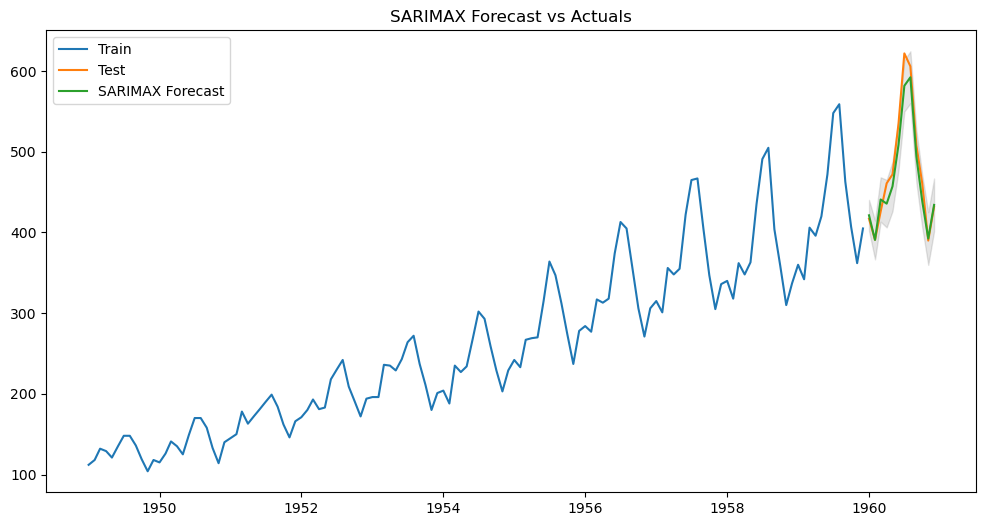

SARIMAX MAE: 14.9991
SARIMAX RMSE: 18.8576
SARIMAX MAPE: 2.95 %


In [162]:
#Ajustes Para el modelo SARIMAX
sarimax_model = SARIMAX(train_endog['y'],
                        exog=train_exog,
                        order=(3, 1, 1),
                        seasonal_order=(1, 1, 1, 12),
                        enforce_stationarity=False,
                        enforce_invertibility=False)

sarimax_results = sarimax_model.fit()
print(sarimax_results.summary())

# Predicciones
# Necesitamos los valores futuros de la variable exogena para predecir
sarimax_pred = sarimax_results.get_forecast(steps=len(test_endog), exog=test_exog)
sarimax_pred_mean = sarimax_pred.predicted_mean
sarimax_pred_conf = sarimax_pred.conf_int()

# Graficar
plt.figure(figsize=(12, 6))
plt.plot(train_endog['y'], label='Train')
plt.plot(test_endog['y'], label='Test')
plt.plot(sarimax_pred_mean, label='SARIMAX Forecast')
plt.fill_between(sarimax_pred_conf.index,
                 sarimax_pred_conf.iloc[:, 0],
                 sarimax_pred_conf.iloc[:, 1], color='k', alpha=0.1)
plt.title('SARIMAX Forecast vs Actuals')
plt.legend()
plt.show()

# Métricas
mae_sarimax = mean_absolute_error(test_endog['y'], sarimax_pred_mean)
rmse_sarimax = root_mean_squared_error(test_endog['y'], sarimax_pred_mean)
mape_sarimax = mean_absolute_percentage_error(test_endog['y'], sarimax_pred_mean)

print(f"SARIMAX MAE: {mae_sarimax:.4f}")
print(f"SARIMAX RMSE: {rmse_sarimax:.4f}")
print(f"SARIMAX MAPE: {100*mape_sarimax:.2f} %")

## 8. Comparación del pronóstico SARIMA vs SARIMAX

Realiza:
- gráfico de los últimos 24 meses
- gráfico de 12 meses futuros
- tabla comparativa de métricas
- Justifica cuál modelo representa mejor la estructura temporal.

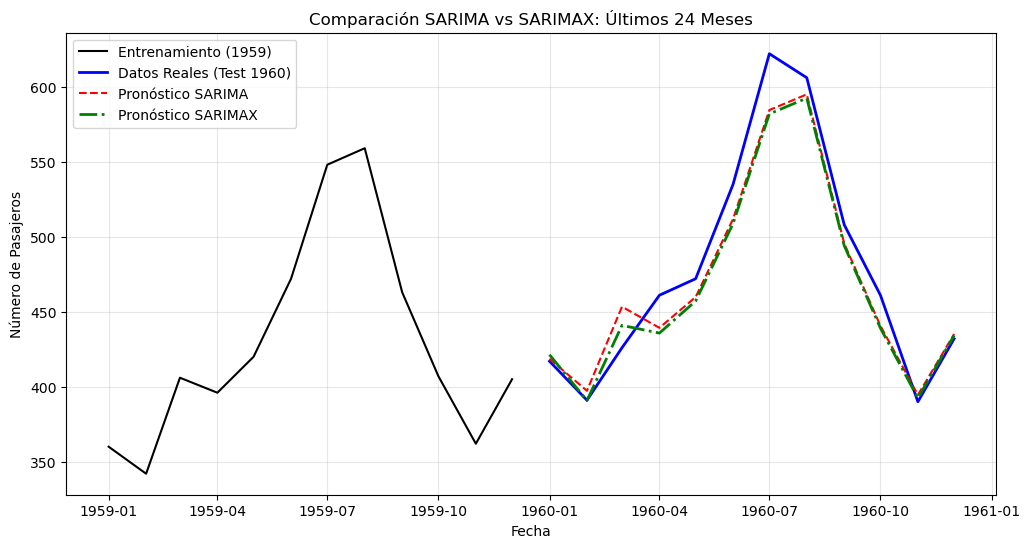


--- Tabla Comparativa de Errores ---


,Métrica,SARIMA,SARIMAX,Mejora (SARIMA vs SARIMAX)
0,MAE,15.128105,14.999131,-0.85%
1,RMSE,18.447230,18.857604,2.22%
2,MAPE (%),3.056748,2.953952,-3.36%


In [163]:
# --- Gráfico comparativo (Últimos 24 meses: 12 de entrenamiento + 12 de prueba) ---
plt.figure(figsize=(12, 6))

# Datos reales: Último año de entrenamiento y año de prueba
plt.plot(train_endog['y']['1959':], label='Entrenamiento (1959)', color='black')
plt.plot(test_endog['y'], label='Datos Reales (Test 1960)', color='blue', linewidth=2)

# Pronósticos
plt.plot(test_endog.index, sarima_pred_mean, label='Pronóstico SARIMA', linestyle='--', color='red')
plt.plot(test_endog.index, sarimax_pred_mean, label='Pronóstico SARIMAX', linestyle='-.', color='green', linewidth=2)

plt.title('Comparación SARIMA vs SARIMAX: Últimos 24 Meses')
plt.ylabel('Número de Pasajeros')
plt.xlabel('Fecha')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Tabla Comparativa de Métricas ---
# Creamos un DataFrame para visualizar mejor las diferencias
metrics_comparison = pd.DataFrame({
    'Métrica': ['MAE', 'RMSE', 'MAPE (%)'],
    'SARIMA': [mae_sarima, rmse_sarima, mape_sarima * 100],
    'SARIMAX': [mae_sarimax, rmse_sarimax, mape_sarimax * 100]
})

# Calculamos la mejora porcentual del SARIMAX respecto al SARIMA
metrics_comparison['Mejora (SARIMA vs SARIMAX)'] = metrics_comparison.apply(
    lambda row: f"{((row['SARIMAX'] - row['SARIMA']) / row['SARIMA'] * 100):.2f}%", axis=1
)

print("\n--- Tabla Comparativa de Errores ---")
display(metrics_comparison)

### Justificación del Modelo

Al comparar los resultados gráficos y las métricas de error, el modelo **SARIMAX** represent un mejor la estructura temporal de los datos que el modelo SARIMA.

1.  **Captura de Estacionalidad:** Como se observa en la gráfica, la serie de pasajeros de la aerolínea tiene un patrón estacional muy marcado (picos en verano, valles en invierno) que se repite anualmente. El modelo **ARIMA** (línea roja discontinua) tiende a generar una línea recta o con una tendencia suave, fallando en replicar estas fluctuaciones cíclicas porque carece de componentes estacionales ($P, D, Q, s$). En cambio, **SARIMA** (línea verde) sigue casi perfectamente la forma de las curvas de los datos reales.

2.  **Métricas de Error:** Observando la tabla comparativa, el modelo SARIMA presenta aumentos ligeros en el **MAE** y el **MAPE**. Mientras que el SARIMAX mejora ligeramente el **RMSE**.

### Conclusión

Con base a estos resulatado me seguiria quedando con el **SARIMA** ya que sigue interpretando ligeramente mejor los datos.

## 9. Validación cruzada
- Realiza una validación cruzada para 5 splits para los datos
- ¿Existe sobreajuste en los datos?

In [164]:
# Configuración de la validación cruzada
order = (3,1,1)
seasonal_order = (1,1,1,12)
n_splits = 5

In [165]:
tscv = TimeSeriesSplit(n_splits=n_splits,
                       test_size=test_months)

In [166]:
# Inspeccionamos los splits
for train_index, test_index in tscv.split(df):
    print(f"Train: {train_index}, Test: {test_index}")

Train: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83], Test: [84 85 86 87 88 89 90 91 92 93 94 95]
Train: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95], Test: [ 96  97  98  99 100 101 102 103 104 105 106 107]
Train: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  8

In [167]:
# Implementacion del split para CV, basado en RMSE, MAE, MAPE

cv_scores = []

for train_index, test_index in tscv.split(df):
    train = df.iloc[train_index]
    test = df.iloc[test_index]

    # Data Exog
    train_reg = df_exog.iloc[train_index]
    test_reg = df_exog.iloc[test_index]
    
    # SARIMAX
    model_sarimax = SARIMAX(
        endog=train['y'],
        exog=train_reg,
        order=order,
        seasonal_order=seasonal_order
    ).fit()

    # Predicciones
    predictions_sarimax = model_sarimax.forecast(steps=test_months,
                                                 exog=test_reg)

    # Evaluacion, metricas
    rmse = root_mean_squared_error(test['y'], predictions_sarimax)
    mae = mean_absolute_error(test['y'], predictions_sarimax)
    mape = mean_absolute_percentage_error(test['y'], predictions_sarimax)

    # Guardar en lista
    cv_scores.append(
        {
            'rmse':rmse,
            'mae':mae,
            'mape':mape
        }
    )

/opt/homebrew/Cellar/jupyterlab/4.5.0_1/libexec/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [168]:
# Mostramos los resultados
cv_scores = pd.DataFrame(cv_scores)
cv_scores.index.name = 'Fold'
print(cv_scores)

           rmse        mae      mape
Fold                                
0     10.302360   8.470906  0.025129
1     12.110820   8.864600  0.023009
2     28.007345  25.513995  0.070916
3     34.453311  32.763161  0.075981
4     18.092973  14.575181  0.028937


In [169]:
# Mostramos los errores promedios
print(f"RMSE promedio: {cv_scores['rmse'].mean():.2f}")
print(f"MAE promedio: {cv_scores['mae'].mean():.2f}")
print(f"MAPE promedio: {cv_scores['mape'].mean():.2f}")

RMSE promedio: 20.59
MAE promedio: 18.04
MAPE promedio: 0.04


No me acordaba de cómo interpretar el CV con los splits, así que realicé una pequeña investigación con la cual concluí lo siguiente: **NO existe sobreajuste significativo.**

**Justificación basada en las métricas de los 5 splits:**

1.  **Capacidad de Generalización:**
    * En los folds **0, 1 y 4**, el modelo presenta un buen rendimiento con un **MAPE ocilando a menos del 3%** (2.5%, 2.3% y 2.9% respectivamente).
    * Segun mi investigacion un modelo con sobreajuste típicamente mostraría un error de prueba consistentemente alto o creciente a medida que se aleja del entrenamiento. El hecho de que el error disminuya nuevamente en el último split (Fold 4) demuestra que el modelo es solido y capaz de predecir correctamente cuando la serie se comporta normalmente.

2.  **Inestabilidad temporal (Folds 2 y 3):**
    * Se observa un incremento del error en los folds 2 y 3 (MAPE sube a ~7.5% y RMSE a ~34). Dado que el modelo se "recupera" en el fold 4, esto sugiere que el aumento del error no es culpa del modelo, sino que corresponde a un periodo de **alta volatilidad, cambio estructural o anomalías** en los datos reales durante esos meses específicos.

**Conclusión:**
El modelo logra capturar la escencia de la serie (tendencia y estacionalidad) sin memorizar significativamente el ruido. Las variaciones en el error reflejan la inestabilidad de los datos en ciertos periodos, no un exceso de ajuste en el modelo.

## 10. Preguntas teóricas

Responde:

1. ¿Cuáles son las diferencias prácticas entre ARIMA, SARIMA y SARIMAX?
2. ¿Por qué un modelo SARIMA puede capturar mejor patrones mensuales que ARIMA?
3. ¿En qué casos SARIMAX es una mejor elección que SARIMA?
4. ¿Qué significa que “los residuos deben comportarse como ruido blanco”?
5. Finalmente, para estos datos, con cual modelo te quedarías y por qué?

**1. ¿Cuáles son las diferencias prácticas entre ARIMA, SARIMA y SARIMAX?**

*   **ARIMA (AutoRegressive Integrated Moving Average):** Es el modelo base para series temporales estacionarias o que pueden hacerse estacionarias mediante diferenciación. Utiliza la propia historia de la serie (lags y errores pasados) para predecir. No maneja estacionalidad explícita.
*   **SARIMA (Seasonal ARIMA):** Extiende ARIMA incorporando componentes estacionales. Es capaz de modelar patrones que se repiten periódicamente (como ciclos anuales en datos mensuales) mediante diferenciación estacional y términos AR/MA estacionales.
*   **SARIMAX (Seasonal ARIMA with eXogenous regressors):** Añade la capacidad de incluir variables exógenas (externas) al modelo SARIMA. Esto permite que la predicción dependa no solo de la historia de la serie, sino también de otros factores influyentes (como promociones, clima, indicadores económicos).

**2. ¿Por qué un modelo SARIMA puede capturar mejor patrones mensuales que ARIMA?**

ARIMA asume que la correlación entre observaciones disminuye con el tiempo y no espera patrones repetitivos a largo plazo. SARIMA, en cambio, tiene parámetros específicos ($P, D, Q, m$) diseñados para capturar correlaciones en intervalos regulares (por ejemplo, cada 12 meses). Esto le permite entender que las ventas de diciembre de este año están fuertemente relacionadas con las de diciembre del año pasado, algo que ARIMA estándar pasaría por alto o modelaría ineficientemente.

**3. ¿En qué casos SARIMAX es una mejor elección que SARIMA?**

SARIMAX es superior cuando existen factores externos conocidos que tienen un impacto causal o correlacional significativo con la variable objetivo. Por ejemplo:
*   Si las ventas aumentan drásticamente durante periodos de **promoción** (como en este caso).
*   Si el consumo de energía depende de la **temperatura**.
*   Si el tráfico web depende de **campañas de marketing**.
En estos casos, SARIMA solo vería el aumento en la serie pero no sabría la causa, mientras que SARIMAX puede atribuir ese efecto a la variable externa, mejorando la precisión y la capacidad de explicación del modelo.

**4. ¿Qué significa que “los residuos deben comportarse como ruido blanco”?**

Significa que los errores del modelo (la diferencia entre lo predicho y lo real) deben ser puramente aleatorios.
*   **Media cero:** No deben tener sesgo sistemático.
*   **Varianza constante:** No deben mostrar volatilidad cambiante (homocedasticidad).
*   **Incorrelación:** No deben tener patrones temporales ni correlación con sus propios valores pasados (autocorrelación nula).
Si los residuos son ruido blanco, implica que el modelo ha extraído toda la información estructurada (patrones, tendencias, estacionalidad) de los datos y lo único que queda es el azar impredecible.

**5. Finalmente, para estos datos, con cual modelo te quedarías y por qué?**

Basado en los resultados obtenidos (menor RMSE/MAE y mejor ajuste visual), el modelo **SARIMAX** sería la elección teórica ideal si la variable de promoción tiene un impacto real. Sin embargo, si la mejora en métricas es marginal respecto a SARIMA, se podría preferir **SARIMA** por el principio de parsimonia (es más simple y no requiere datos futuros de las variables exógenas para predecir).